# 1. Imports & Dataset Loading


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

# 2. Initial Dataset Inspection
    - head()
    - shape
    - info()
    - describe()
    - missing values
    - duplicates

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine Failure is Highly Unbalanced hence the model will be biased towards predicting no failure is not balanced 

In [6]:
df["Machine failure"].mean()

np.float64(0.0339)

In [7]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [8]:
categorical_cols = [columns for columns in df.columns if df[columns].dtype == 'object']
numerical_cols = [columns for columns in df.columns if df[columns].dtype != 'object']
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Product ID', 'Type']
Numerical columns: ['UDI', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [9]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


# 3. Exploratory Data Analysis
    - target distribution
    - numerical distributions
    - boxplots
    - correlations
    - feature vs failure analysis

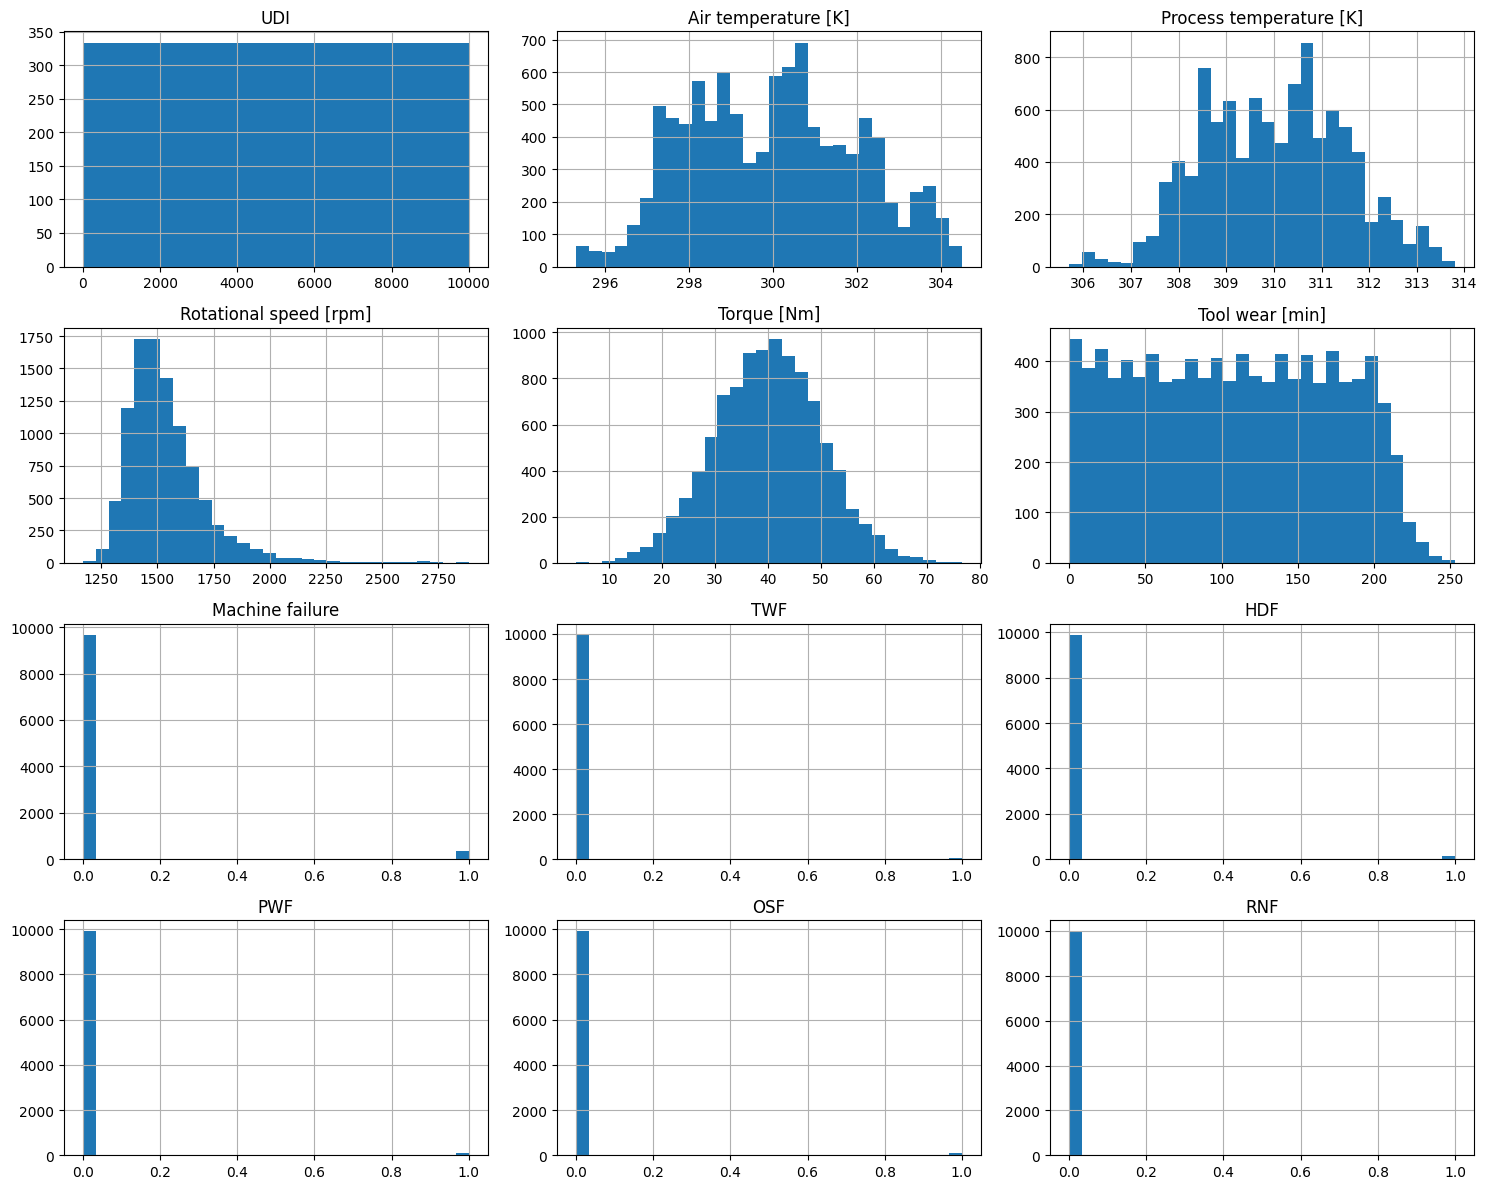

In [12]:
df[numerical_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

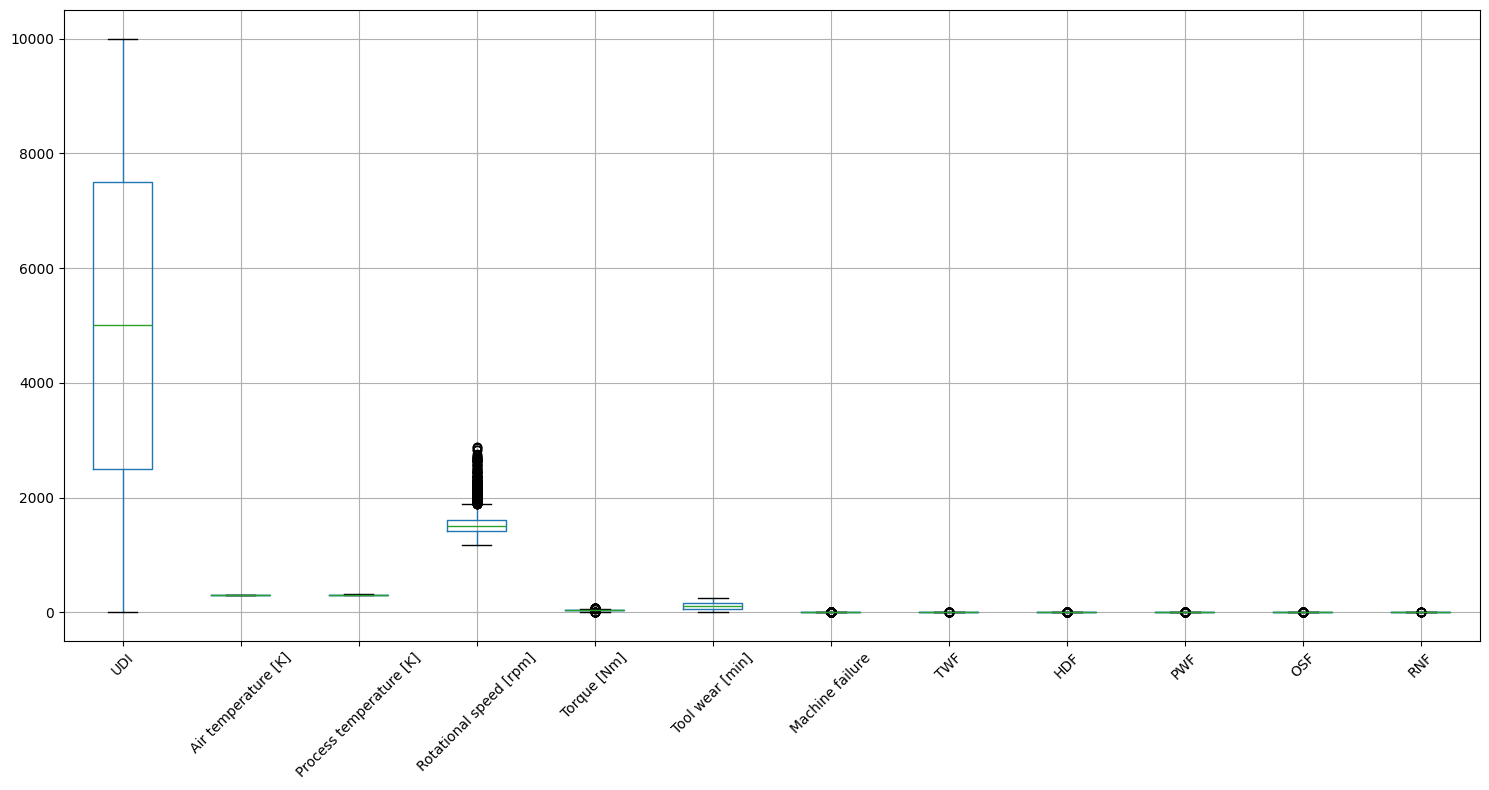

In [13]:
plt.figure(figsize=(15, 8))

df[numerical_cols].boxplot()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

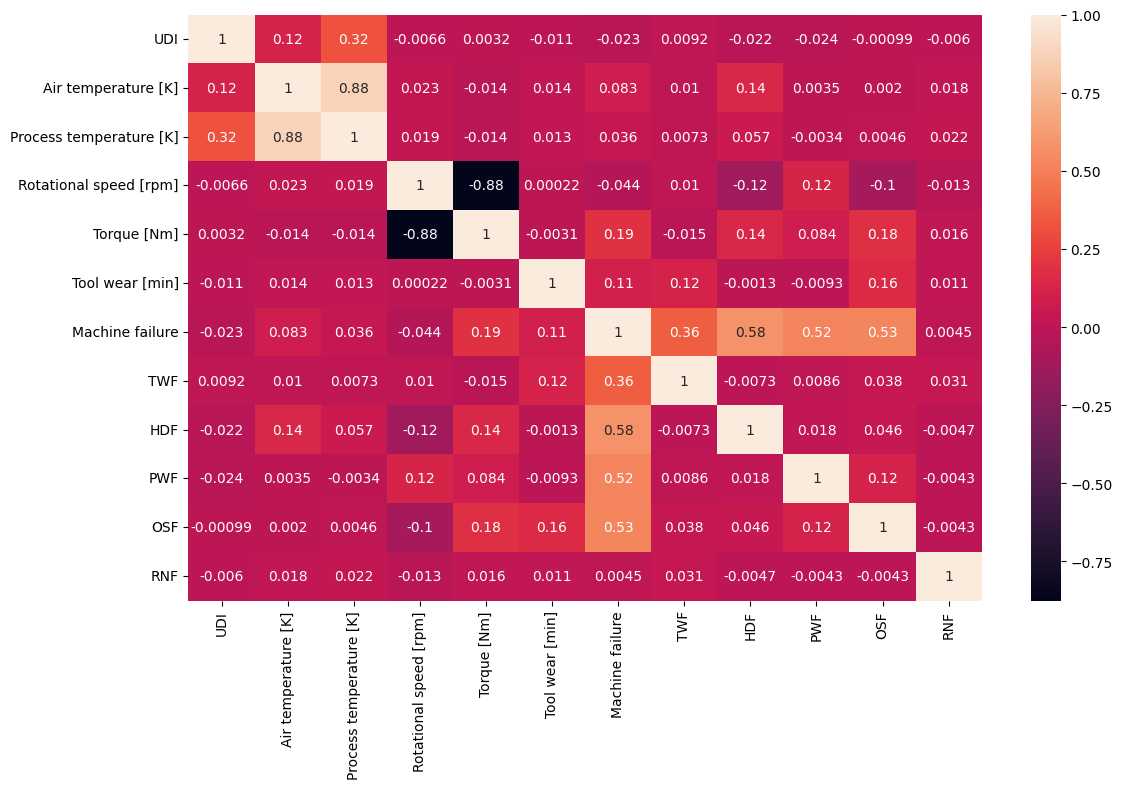

In [14]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True
)

plt.tight_layout()
plt.show()

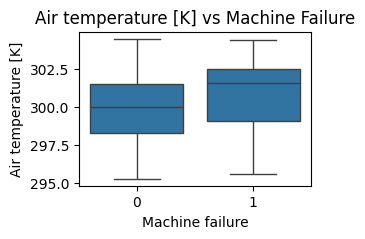

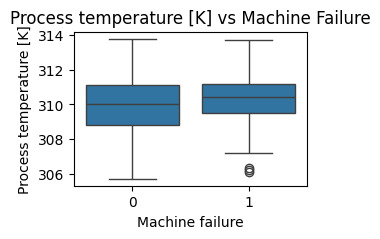

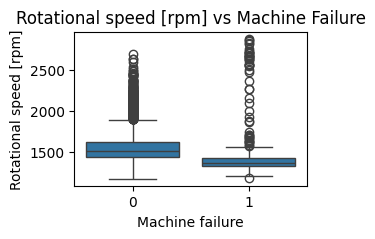

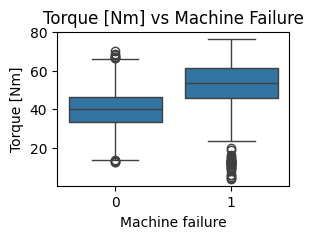

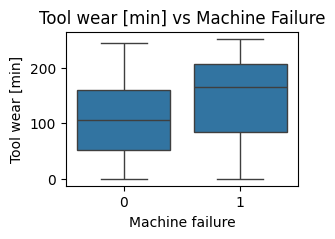

In [15]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for feature in features:
    plt.figure(figsize=(3, 2))
    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature
    )
    plt.title(f"{feature} vs Machine Failure")
    plt.show()

In [16]:
failure_by_type = pd.crosstab(
    df["Type"],
    df["Machine failure"],
    normalize="index"
) * 100

failure_by_type

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


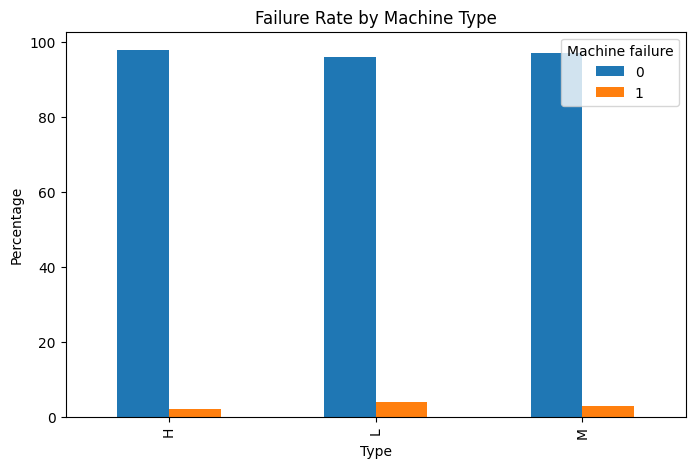

In [17]:
failure_by_type.plot(
    kind="bar",
    figsize=(8, 5)
)
plt.ylabel("Percentage")
plt.title("Failure Rate by Machine Type")
plt.show()

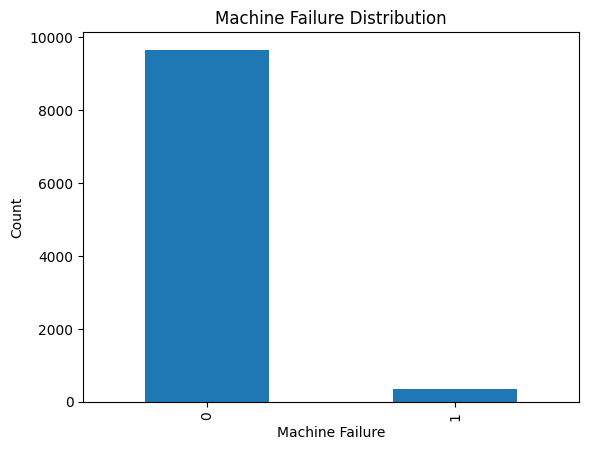

In [18]:
df["Machine failure"].value_counts().plot(
    kind="bar",
    title="Machine Failure Distribution"
)

plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [21]:
df.columns.to_list()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

## EDA Findings

- The dataset contains 10,000 observations and 14 columns.
- No missing values were observed.
- No duplicate observations were detected.
- The target variable `Machine failure` is highly imbalanced, with
  approximately 3.39% positive failure cases.
- `UDI` is an identifier and is not expected to provide meaningful
  predictive information.
- `Product ID` is an identifier-like feature and will be investigated
  before preprocessing.
- `Type` is a categorical feature that may contain useful information
  about machine characteristics.
- The main numerical sensor features are air temperature, process
  temperature, rotational speed, torque, and tool wear.
- Extreme sensor values should not automatically be removed because
  abnormal operating conditions may be predictive of machine failure.
- The failure-mode columns `TWF`, `HDF`, `PWF`, `OSF`, and `RNF` are
  associated with specific failure mechanisms and will be excluded
  from the predictive feature set to avoid information leakage.

# 4. Data Preparation     
    - remove irrelevant/leakage columns
    - separate X and y
    - train/test split
    - identify categorical/numerical features


In [22]:
drop_cols = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]
df_model = df.drop(columns=drop_cols)
df_model.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

In [23]:
X = df_model.drop(columns = ["Machine failure"])
y = df_model["Machine failure"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 6)
y shape: (10000,)


In [24]:
y.value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y
)

In [26]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\ny_test:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (8000, 6)
X_test : (2000, 6)

y_train:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

y_test:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


In [27]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [29]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original training shape: (8000, 6)
Processed training shape: (8000, 8)
Original test shape: (2000, 6)
Processed test shape: (2000, 8)


In [30]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__Air temperature [K]', 'num__Process temperature [K]',
       'num__Rotational speed [rpm]', 'num__Torque [Nm]',
       'num__Tool wear [min]', 'cat__Type_H', 'cat__Type_L',
       'cat__Type_M'], dtype=object)

# Baseline Model -  Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [32]:
logistic_model = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
y_pred = logistic_model.predict(X_test_processed)
y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3

In [34]:
decision_values = logistic_model.decision_function(X_test_processed)

/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [35]:
y_pred = logistic_model.predict(X_test_processed)

/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [36]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, decision_values))
print("PR-AUC   :", average_precision_score(y_test, decision_values))
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Failure", "Failure"]
    )
)

Accuracy : 0.9675
Precision: 0.6363636363636364
Recall   : 0.10294117647058823
F1 Score : 0.17721518987341772
ROC-AUC  : 0.8994184630373888
PR-AUC   : 0.42338557046987174
              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1932
     Failure       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1928    4]
 [  61    7]]


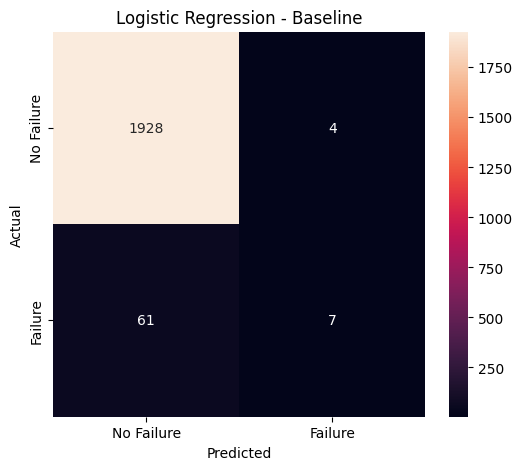

In [38]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Baseline")

plt.show()

In [39]:
print("First 10 predicted probabilities:")
print(y_prob[:10])

print("\nProbability range:")
print(y_prob.min(), y_prob.max())

First 10 predicted probabilities:
[5.97291882e-01 3.14004290e-02 5.22524323e-02 3.67289369e-04
 1.96122641e-01 4.08188477e-02 8.13293575e-02 6.61224488e-03
 2.11570765e-03 6.55956691e-02]

Probability range:
5.517228229605551e-05 0.9461708654929184


In [40]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob)
}

baseline_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.9675,
 'Precision': 0.6363636363636364,
 'Recall': 0.10294117647058823,
 'F1': 0.17721518987341772,
 'ROC-AUC': 0.8994184630373888,
 'PR-AUC': 0.42338557046987174}

                    Baseline
                       │
             Logistic Regression
                       │
                       ▼
               Evaluate metrics
                       │
                       ▼
            Handle class imbalance
             /                  \
       Class weights           SMOTE
             \                  /
              ▼                ▼
             Compare results
                    │
                    ▼
              Random Forest
                    │
                    ▼
                 XGBoost
                    │
                    ▼
             Hyperparameter tuning
                    │
                    ▼
           Threshold optimization
                    │
                    ▼
             Final ML model

# Handle Class Imbalance - Class weights

In [41]:
balanced_logistic = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
balanced_logistic.fit(
    X_train_processed,
    y_train
)
y_pred_balanced = balanced_logistic.predict(X_test_processed)
decision_balanced = balanced_logistic.decision_function(
    X_test_processed
)

/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3

In [42]:
print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall   :", recall_score(y_test, y_pred_balanced))
print("F1 Score :", f1_score(y_test, y_pred_balanced))
print("ROC-AUC  :", roc_auc_score(y_test, decision_balanced))
print("PR-AUC   :", average_precision_score(y_test, decision_balanced))

Accuracy : 0.824
Precision: 0.1414141414141414
Recall   : 0.8235294117647058
F1 Score : 0.2413793103448276
ROC-AUC  : 0.9069464742418707
PR-AUC   : 0.38179015732339133


In [43]:
print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=["No Failure", "Failure"]
    )
)

              precision    recall  f1-score   support

  No Failure       0.99      0.82      0.90      1932
     Failure       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



[[1592  340]
 [  12   56]]


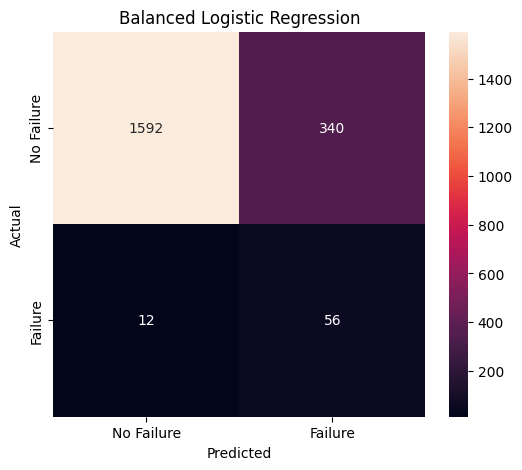

In [44]:
cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced
)
print(cm_balanced)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Logistic Regression")

plt.show()

# Try SMOTE

In [45]:
!pip install imbalanced-learn

In [46]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("Before SMOTE:", X_train_processed.shape)
print("After SMOTE :", X_train_smote.shape)


Before SMOTE:
Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64
Before SMOTE: (8000, 8)
After SMOTE : (15458, 8)


# Train SMOTE + Logistic Regression

In [47]:
smote_logistic = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=42
)
smote_logistic.fit(
    X_train_smote,
    y_train_smote
)
smote_logistic.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_logistic.predict(
    X_test_processed
)
decision_smote = smote_logistic.decision_function(
    X_test_processed
)

/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/krishna/Desktop/industrial-predictive-maintenance/venv/lib/python3

In [48]:
print("SMOTE + Logistic Regression")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall   :", recall_score(y_test, y_pred_smote))
print("F1 Score :", f1_score(y_test, y_pred_smote))
print("ROC-AUC  :", roc_auc_score(y_test, decision_smote))
print("PR-AUC   :", average_precision_score(y_test, decision_smote))

SMOTE + Logistic Regression
----------------------------------------
Accuracy : 0.829
Precision: 0.14507772020725387
Recall   : 0.8235294117647058
F1 Score : 0.24669603524229075
ROC-AUC  : 0.907707648276702
PR-AUC   : 0.38306246865897536



Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.83      0.90      1932
     Failure       0.15      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000


Confusion Matrix:
[[1602  330]
 [  12   56]]


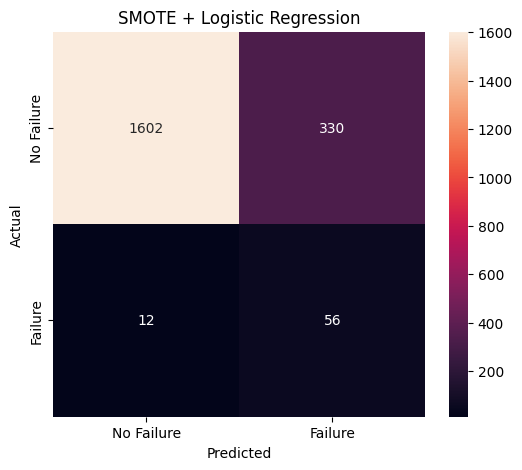

In [49]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=["No Failure", "Failure"]
    )
)
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

print("\nConfusion Matrix:")
print(cm_smote)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SMOTE + Logistic Regression")

plt.show()

| Model                        |   Accuracy |  Precision |     Recall |     F1 |
| ---------------------------- | ---------: | ---------: | ---------: | -----: |
| Logistic Regression          | **96.75%** | **63.64%** |     10.29% | 17.72% |
| Balanced Logistic Regression |     82.40% |     14.14% | **82.35%** | 24.14% |
| SMOTE + Logistic Regression  |     83.00% |    ~14.51% | **82.35%** | ~24.8% |


# Random Forest:

In [50]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(
    X_train_processed,
    y_train
)
y_pred_rf = rf_model.predict(X_test_processed)
decision_rf = rf_model.predict_proba(X_test_processed)[:, 1]

Random Forest
----------------------------------------
Accuracy : 0.9815
Precision: 0.8974358974358975
Recall   : 0.5147058823529411
F1 Score : 0.6542056074766355
ROC-AUC  : 0.97064532334673
PR-AUC   : 0.7918241097395442
              precision    recall  f1-score   support

  No Failure       0.98      1.00      0.99      1932
     Failure       0.90      0.51      0.65        68

    accuracy                           0.98      2000
   macro avg       0.94      0.76      0.82      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:
[[1928    4]
 [  33   35]]


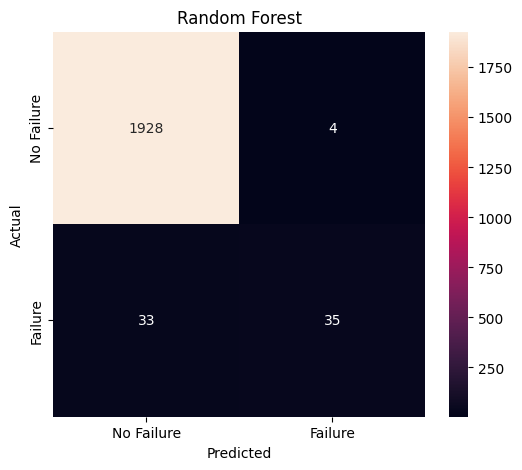

In [51]:
print("Random Forest")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, decision_rf))
print("PR-AUC   :", average_precision_score(y_test, decision_rf))

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No Failure", "Failure"]
    )
)

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest")

plt.show()

| Model                        | Precision |    Recall |        F1 |   ROC-AUC |    PR-AUC |
| ---------------------------- | --------: | --------: | --------: | --------: | --------: |
| Logistic Regression          |     63.6% |     10.3% |     17.7% |     89.9% |     42.3% |
| Balanced Logistic Regression |     14.1% | **82.4%** |     24.1% |     90.7% |     38.2% |
| SMOTE + Logistic Regression  |    ~14.5% | **82.4%** |      ~25% |         — |         — |
| **Random Forest**            | **89.7%** |     51.5% | **65.4%** | **97.1%** | **79.2%** |


# Random Forest with class weighting

In [52]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(
    X_train_processed,
    y_train
)
y_pred_rf_balanced = rf_balanced.predict(
    X_test_processed
)

decision_rf_balanced = rf_balanced.predict_proba(
    X_test_processed
)[:, 1]

In [53]:
print("Random Forest - Balanced")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf_balanced))
print("Precision:", precision_score(y_test, y_pred_rf_balanced))
print("Recall   :", recall_score(y_test, y_pred_rf_balanced))
print("F1 Score :", f1_score(y_test, y_pred_rf_balanced))
print("ROC-AUC  :", roc_auc_score(y_test, decision_rf_balanced))
print("PR-AUC   :", average_precision_score(y_test, decision_rf_balanced))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_balanced,
        target_names=["No Failure", "Failure"]
    )
)

cm_rf_balanced = confusion_matrix(
    y_test,
    y_pred_rf_balanced
)

print("\nConfusion Matrix:")
print(cm_rf_balanced)

Random Forest - Balanced
----------------------------------------
Accuracy : 0.9805
Precision: 0.8918918918918919
Recall   : 0.4852941176470588
F1 Score : 0.6285714285714286
ROC-AUC  : 0.9626111314090855
PR-AUC   : 0.7771802389790942

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.98      1.00      0.99      1932
     Failure       0.89      0.49      0.63        68

    accuracy                           0.98      2000
   macro avg       0.94      0.74      0.81      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:
[[1928    4]
 [  35   33]]


# Random Forest - Balanced on the SMOTE-balanced training set:

In [54]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf_smote = rf_smote.predict(X_test_processed)

y_prob_rf_smote = rf_smote.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest + SMOTE")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf_smote))
print("Precision:", precision_score(y_test, y_pred_rf_smote))
print("Recall   :", recall_score(y_test, y_pred_rf_smote))
print("F1 Score :", f1_score(y_test, y_pred_rf_smote))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf_smote))
print("PR-AUC   :", average_precision_score(y_test, y_prob_rf_smote))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_smote,
        target_names=["No Failure", "Failure"]
    )
)

cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)

print("\nConfusion Matrix:")
print(cm_rf_smote)

Random Forest + SMOTE
----------------------------------------
Accuracy : 0.9665
Precision: 0.5050505050505051
Recall   : 0.7352941176470589
F1 Score : 0.5988023952095808
ROC-AUC  : 0.9720496894409938
PR-AUC   : 0.7280455670633066

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1932
     Failure       0.51      0.74      0.60        68

    accuracy                           0.97      2000
   macro avg       0.75      0.85      0.79      2000
weighted avg       0.97      0.97      0.97      2000


Confusion Matrix:
[[1883   49]
 [  18   50]]


# XGBoost baseline

In [55]:
!pip install xgboost

In [57]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train_processed,
    y_train
)
y_pred_xgb = xgb_model.predict(
    X_test_processed
)

y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

XGBoost
----------------------------------------
Accuracy : 0.987
Precision: 0.9038461538461539
Recall   : 0.6911764705882353
F1 Score : 0.7833333333333333
ROC-AUC  : 0.9753227377907685
PR-AUC   : 0.8517752933103662

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.90      0.69      0.78        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
[[1927    5]
 [  21   47]]


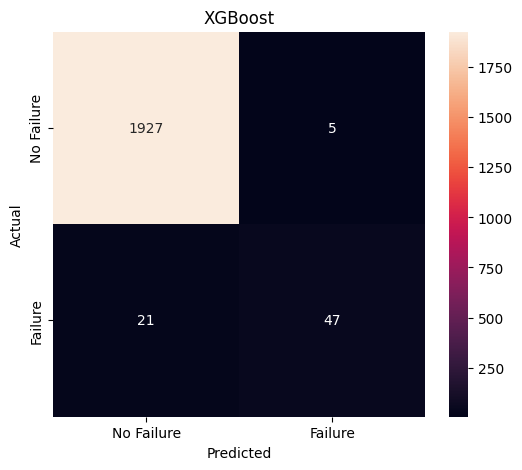

In [58]:
print("XGBoost")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC   :", average_precision_score(y_test, y_prob_xgb))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["No Failure", "Failure"]
    )
)

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("\nConfusion Matrix:")
print(cm_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost")

plt.show()

| Metric    |    XGBoost | Random Forest |
| --------- | ---------: | ------------: |
| Accuracy  | **98.70%** |        98.15% |
| Precision | **90.38%** |        89.74% |
| Recall    | **69.12%** |        51.47% |
| F1        | **78.33%** |        65.42% |
| ROC-AUC   | **97.53%** |        97.06% |
| PR-AUC    | **85.18%** |        79.18% |


| Model               | Precision |    Recall |        F1 |    PR-AUC |
| ------------------- | --------: | --------: | --------: | --------: |
| Logistic Regression |     63.6% |     10.3% |     17.7% |     42.3% |
| Balanced LR         |     14.1% |     82.4% |     24.1% |     38.2% |
| SMOTE + LR          |    ~14.5% |     82.4% |      ~25% |         — |
| Random Forest       |     89.7% |     51.5% |     65.4% |     79.2% |
| Balanced RF         |     89.2% |     48.5% |     62.9% |     77.7% |
| SMOTE + RF          |     50.5% |     73.5% |     59.9% |     72.8% |
| **XGBoost**         | **90.4%** | **69.1%** | **78.3%** | **85.2%** |


# Handle class imbalance in XGBoost
### Now I would not use SMOTE first.
### XGBoost has its own mechanism specifically designed for imbalanced binary classification:


In [59]:
xgb_balanced = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=7729/271,
    random_state=42,
    n_jobs=-1
)

xgb_balanced.fit(
    X_train_processed,
    y_train
)

y_pred_xgb_balanced = xgb_balanced.predict(
    X_test_processed
)

y_prob_xgb_balanced = xgb_balanced.predict_proba(
    X_test_processed
)[:, 1]

In [60]:
print("XGBoost - Balanced")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb_balanced))
print("Precision:", precision_score(y_test, y_pred_xgb_balanced))
print("Recall   :", recall_score(y_test, y_pred_xgb_balanced))
print("F1 Score :", f1_score(y_test, y_pred_xgb_balanced))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb_balanced))
print("PR-AUC   :", average_precision_score(y_test, y_prob_xgb_balanced))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb_balanced,
        target_names=["No Failure", "Failure"]
    )
)

cm_xgb_balanced = confusion_matrix(
    y_test,
    y_pred_xgb_balanced
)

print("\nConfusion Matrix:")
print(cm_xgb_balanced)

XGBoost - Balanced
----------------------------------------
Accuracy : 0.977
Precision: 0.627906976744186
Recall   : 0.7941176470588235
F1 Score : 0.7012987012987013
ROC-AUC  : 0.9673608573864328
PR-AUC   : 0.8196548661875862

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.63      0.79      0.70        68

    accuracy                           0.98      2000
   macro avg       0.81      0.89      0.84      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:
[[1900   32]
 [  14   54]]


| Metric    |    XGBoost | XGBoost + `scale_pos_weight` |
| --------- | ---------: | ---------------------------: |
| Accuracy  | **98.70%** |                       97.70% |
| Precision | **90.38%** |                       62.79% |
| Recall    |     69.12% |                   **79.41%** |
| F1        | **78.33%** |                       70.13% |
| ROC-AUC   | **97.53%** |                       96.74% |
| PR-AUC    | **85.18%** |                       81.97% |


# Next: XGBoost Hyperparameter Tuning

In [61]:
from sklearn.model_selection import RandomizedSearchCV

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=25,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(
    X_train_processed,
    y_train
)

print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest CV F1:")
print(xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best parameters:
{'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}

Best CV F1:
0.6989291568777153


XGBoost - Tuned
----------------------------------------
Accuracy : 0.987
Precision: 0.9038461538461539
Recall   : 0.6911764705882353
F1 Score : 0.7833333333333333
ROC-AUC  : 0.9766167336499818
PR-AUC   : 0.8399693340549144

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.90      0.69      0.78        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
[[1927    5]
 [  21   47]]


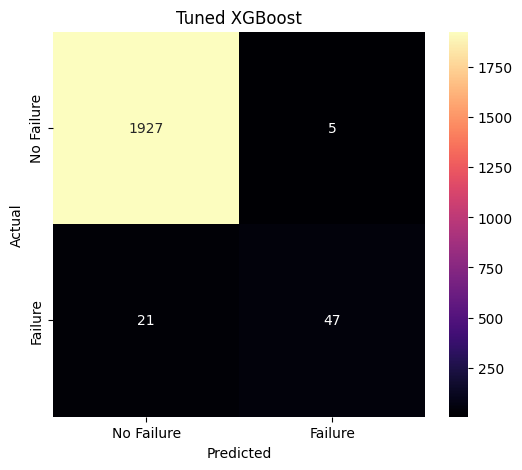

In [62]:
best_xgb = xgb_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test_processed)
y_prob_tuned = best_xgb.predict_proba(X_test_processed)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

print("XGBoost - Tuned")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))
print("PR-AUC   :", average_precision_score(y_test, y_prob_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["No Failure", "Failure"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned XGBoost")
plt.show()

In [63]:
results = {
    "Logistic Regression": {
        "Accuracy": 0.9675,
        "Precision": 0.6364,
        "Recall": 0.1029,
        "F1": 0.1772,
        "ROC-AUC": 0.8994,
        "PR-AUC": 0.4234
    },
    
    "Balanced Logistic Regression": {
        "Accuracy": 0.824,
        "Precision": 0.1414,
        "Recall": 0.8235,
        "F1": 0.2414,
        "ROC-AUC": 0.9069,
        "PR-AUC": 0.3818
    },
    
    "SMOTE + Logistic Regression": {
        "Accuracy": 0.824,
        "Precision": 0.151,
        "Recall": 0.8235,
        "F1": 0.25,
        "ROC-AUC": None,
        "PR-AUC": None
    },
    
    "Random Forest": {
        "Accuracy": 0.9815,
        "Precision": 0.8974,
        "Recall": 0.5147,
        "F1": 0.6542,
        "ROC-AUC": 0.9706,
        "PR-AUC": 0.7918
    },
    
    "Balanced Random Forest": {
        "Accuracy": 0.9805,
        "Precision": 0.8919,
        "Recall": 0.4853,
        "F1": 0.6286,
        "ROC-AUC": 0.9626,
        "PR-AUC": 0.7772
    },
    
    "SMOTE + Random Forest": {
        "Accuracy": 0.9665,
        "Precision": 0.5051,
        "Recall": 0.7353,
        "F1": 0.5988,
        "ROC-AUC": 0.9720,
        "PR-AUC": 0.7280
    },
    
    "XGBoost": {
        "Accuracy": 0.987,
        "Precision": 0.9038,
        "Recall": 0.6912,
        "F1": 0.7833,
        "ROC-AUC": 0.9753,
        "PR-AUC": 0.8518
    },
    
    "Balanced XGBoost": {
        "Accuracy": 0.977,
        "Precision": 0.6279,
        "Recall": 0.7941,
        "F1": 0.7013,
        "ROC-AUC": 0.9674,
        "PR-AUC": 0.8197
    },
    
    "Tuned XGBoost": {
        "Accuracy": 0.987,
        "Precision": 0.9038,
        "Recall": 0.6912,
        "F1": 0.7833,
        "ROC-AUC": 0.9766,
        "PR-AUC": 0.8400
    }
}

In [64]:
results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
XGBoost,0.9870,0.9038,0.6912,0.7833,0.9753,0.8518
Tuned XGBoost,0.9870,0.9038,0.6912,0.7833,0.9766,0.8400
Balanced XGBoost,0.9770,0.6279,0.7941,0.7013,0.9674,0.8197
Random Forest,0.9815,0.8974,0.5147,0.6542,0.9706,0.7918
Balanced Random Forest,0.9805,0.8919,0.4853,0.6286,0.9626,0.7772
SMOTE + Random Forest,0.9665,0.5051,0.7353,0.5988,0.9720,0.7280
SMOTE + Logistic Regression,0.8240,0.1510,0.8235,0.2500,NaN,NaN
Balanced Logistic Regression,0.8240,0.1414,0.8235,0.2414,0.9069,0.3818
Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8994,0.4234


In [66]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 8
['num__Air temperature [K]' 'num__Process temperature [K]'
 'num__Rotational speed [rpm]' 'num__Torque [Nm]' 'num__Tool wear [min]'
 'cat__Type_H' 'cat__Type_L' 'cat__Type_M']


In [67]:
feature_importance = pd.Series(
    best_xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feature_importance)

num__Torque [Nm]                0.240041
num__Rotational speed [rpm]     0.179528
num__Tool wear [min]            0.164450
num__Air temperature [K]        0.135768
num__Process temperature [K]    0.090068
cat__Type_L                     0.079746
cat__Type_M                     0.076186
cat__Type_H                     0.034212
dtype: float32


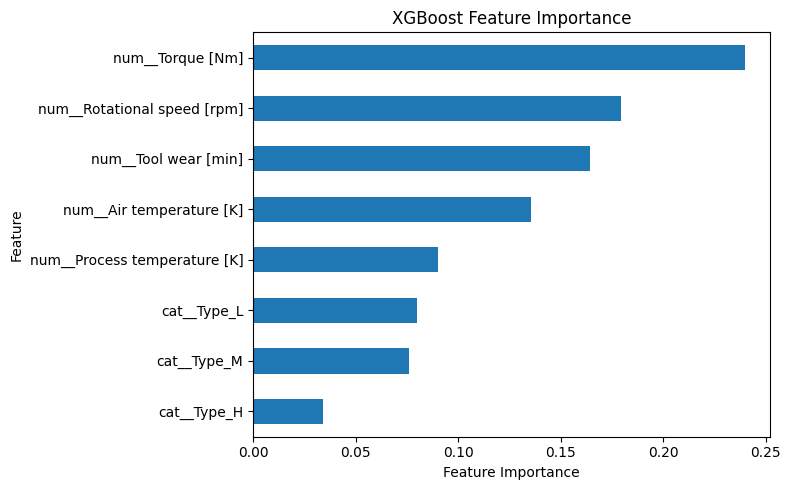

In [70]:
plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [71]:
print("Top 5 features:")
print(feature_importance.head(5))

Top 5 features:
num__Torque [Nm]                0.240041
num__Rotational speed [rpm]     0.179528
num__Tool wear [min]            0.164450
num__Air temperature [K]        0.135768
num__Process temperature [K]    0.090068
dtype: float32


## Next step: SHAP analysis
This is the next level of model interpretation. It will answer:
Which features generally push predictions toward Failure?
Which features push predictions toward No Failure?
For an individual machine observation, why did the model predict failure?
First check whether SHAP is installed.


In [75]:
!pip install shap
import shap

In [77]:
import shap
import xgboost

print("SHAP:", shap.__version__)
print("XGBoost:", xgboost.__version__)

SHAP: 0.49.1
XGBoost: 3.2.0


In [78]:
import xgboost as xgb
import numpy as np

booster = best_xgb.get_booster()

dmatrix_test = xgb.DMatrix(
    X_test_processed
)

shap_values = booster.predict(
    dmatrix_test,
    pred_contribs=True
)

print("SHAP shape:", shap_values.shape)

SHAP shape: (2000, 9)


Feature SHAP shape: (2000, 8)


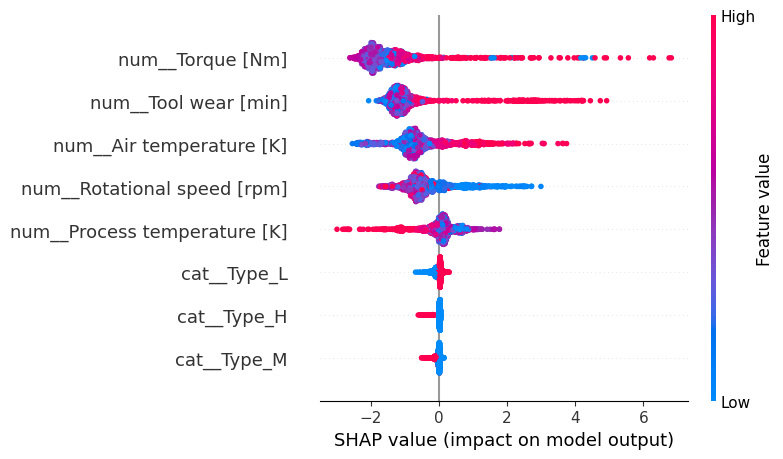

In [80]:
shap_values_features = shap_values[:, :-1]

print("Feature SHAP shape:", shap_values_features.shape)

shap.summary_plot(
    shap_values_features,
    X_test_processed,
    feature_names=feature_names
)

## More importantly: direction of influence
Torque: High values (red) extend strongly toward the positive SHAP side → high torque tends to push the model toward predicting Failure (class 1).
Tool wear: High tool wear strongly pushes toward Failure.
Air temperature: Higher air temperature generally pushes toward Failure.
Rotational speed: Here the pattern is interesting: lower rotational speed (blue) tends to have more positive SHAP values, while higher speed (red) tends toward the negative side.
Process temperature: Higher process temperature tends to push toward the negative SHAP side, i.e. toward No Failure.
The Type variables have relatively small influence compared with the numerical sensor features.

In [81]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + SMOTE",
        "Random Forest",
        "Random Forest + Balanced",
        "Random Forest + SMOTE",
        "XGBoost",
        "XGBoost Tuned"
    ],
    "Accuracy": [
        0.9675,
        0.8240,
        0.9815,
        0.9805,
        0.9665,
        0.9870,
        0.9870
    ],
    "Precision": [
        0.6364,
        0.1414,
        0.8974,
        0.8919,
        0.5051,
        0.9038,
        0.9038
    ],
    "Recall": [
        0.1029,
        0.8235,
        0.5147,
        0.4853,
        0.7353,
        0.6912,
        0.6912
    ],
    "F1": [
        0.1772,
        0.2414,
        0.6542,
        0.6286,
        0.5988,
        0.7833,
        0.7833
    ],
    "ROC_AUC": [
        0.8994,
        0.9069,
        0.9706,
        0.9626,
        0.9720,
        0.9753,
        0.9766
    ],
    "PR_AUC": [
        0.4234,
        0.3818,
        0.7918,
        0.7772,
        0.7280,
        0.8518,
        0.8400
    ]
})

results.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
5,XGBoost,0.9870,0.9038,0.6912,0.7833,0.9753,0.8518
6,XGBoost Tuned,0.9870,0.9038,0.6912,0.7833,0.9766,0.8400
2,Random Forest,0.9815,0.8974,0.5147,0.6542,0.9706,0.7918
3,Random Forest + Balanced,0.9805,0.8919,0.4853,0.6286,0.9626,0.7772
4,Random Forest + SMOTE,0.9665,0.5051,0.7353,0.5988,0.9720,0.7280
1,Logistic Regression + SMOTE,0.8240,0.1414,0.8235,0.2414,0.9069,0.3818
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772,0.8994,0.4234


# Save them:

In [82]:
import pickle

with open("xgb_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)

with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

# Load the saved Object :

In [83]:
import pickle

with open("xgb_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

with open("preprocessor.pkl", "rb") as f:
    loaded_preprocessor = pickle.load(f)

In [84]:
sample_machine = pd.DataFrame({
    "Type": ["M"],
    "Air temperature [K]": [300.0],
    "Process temperature [K]": [310.0],
    "Rotational speed [rpm]": [1500],
    "Torque [Nm]": [50.0],
    "Tool wear [min]": [150]
})

sample_machine

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,300.0,310.0,1500,50.0,150


In [85]:
sample_processed = loaded_preprocessor.transform(
    sample_machine
)
print(sample_processed)

[[-0.00272948 -0.00409811 -0.21747538  0.99777602  0.66524623  0.
   0.          1.        ]]


In [86]:
prediction = loaded_model.predict(sample_processed)[0]

probability = loaded_model.predict_proba(
    sample_processed
)[0, 1]

print("Prediction:", prediction)
print("Failure probability:", probability)

Prediction: 0
Failure probability: 0.00086723367
